In [1]:
import sys
import os

sys.path.append(os.path.realpath(os.path.join(os.getcwd(), '..', '..', '..', 'T5000', 'T5000-Base', 'Pylians3', 'library')))
sys.path.append(os.path.abspath('../src'))

from pathlib import Path
from tqdm import tqdm

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.utils import load_config
from src.validation import get_tpcf

import MAS_library as MASL
import Pk_library as PKL

/home/bartb/venvs/boids/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
WIDTH_LATEX = 4.9
FONT_COLOR = "0" # or "#0E1D35" for the dark blue as per pp theme

In [3]:
def find_equally_spaced_indices(arr, n):
    "Based on specific conditioning parameter."
    sorted_indices = np.argsort(arr)
    sorted_arr = arr[sorted_indices]
    min_val, max_val = sorted_arr[0], sorted_arr[-1]
    division_points = np.linspace(min_val, max_val, n)
    closest_indices = np.searchsorted(sorted_arr, division_points)
    closest_indices = np.clip(closest_indices, 0, len(arr) - 1)
    original_indices = sorted_indices[closest_indices]
    return original_indices

def compute_pk_from_positions(pos_normalized, n_halos):
    pos_phys = (pos_normalized * BoxSize).astype(np.float32)
    delta = np.zeros((grid, grid, grid), dtype=np.float32)
    MASL.MA(pos_phys, delta, BoxSize, MAS=MAS)
    delta /= np.mean(delta, dtype=np.float64)
    delta -= 1.0

    devnull = open(os.devnull, 'w')
    old_stdout = sys.stdout
    sys.stdout = devnull
    Pk = PKL.Pk(delta, BoxSize, axis=0, MAS=MAS, threads=4)
    sys.stdout = old_stdout
    devnull.close()

    shot_noise = BoxSize**3 / n_halos
    return Pk.k3D, Pk.Pk[:, 0], shot_noise

In [4]:
train_run = "20260508_154857"
infer_run = "20260510_140248"
config_dir = f"/gpfs/home4/bartb/T256/T256-SUBBOX/results/run_{train_run}/qualitative_2pcf/{infer_run}/final_config.yaml"
config = load_config(config_dir)

gen_samples = torch.load(
    f"/gpfs/home4/bartb/T256/T256-SUBBOX/results/run_{train_run}/qualitative_2pcf/{infer_run}/gen_samples.pth",
    weights_only=False)

true_samples = torch.from_numpy(
    np.load("/gpfs/home4/bartb/T256/Data/subboxes/test_subbox_halos.npy")[..., :3])
halo_counts = np.load("/gpfs/home4/bartb/T256/Data/subboxes/test_subbox_counts.npy")
params = pd.read_csv("/gpfs/home4/bartb/T256/Data/subboxes/test_cosmology.csv").values


In [5]:
BoxSize = 370.0
grid = 128
MAS = 'CIC'
n_halos = 5000
shot_noise = BoxSize**3 / n_halos

In [6]:
equally_spaced = 20
params_idx_used = find_equally_spaced_indices(params[:, 0], equally_spaced)
params_used = params[params_idx_used][::4]
eval_cosm = params_used
n_eval = eval_cosm.shape[0]

cosm_tol = 1e-4
subbox_indices_per_cosm = []
mean_halo_counts = []

for i in range(n_eval):
    diffs = np.abs(params - eval_cosm[i])
    matches = np.all(diffs < cosm_tol, axis=1)
    indices = np.where(matches)[0]
    subbox_indices_per_cosm.append(indices)
    mean_halo_counts.append(int(np.round(np.mean(halo_counts[indices]))))

n_repeats = config["inference"]["n_repeats"]
print(f"n_eval={n_eval}, n_repeats={n_repeats}")

n_eval=5, n_repeats=20


In [8]:
# n_cosmologies = true_samples_used.shape[0]
n_cosmologies = 5
n_repeats = config["inference"]["n_repeats"]
print(f"Number of cosmologies: {n_cosmologies}, Number of repeats: {n_repeats}") 

Number of cosmologies: 5, Number of repeats: 20


In [9]:
pk_true_avg = {}
pk_true_std = {}
pk_gen = {}
k_vals = None

for i in range(n_eval):
    # --- Ground truth: average over all matching subboxes ---
    indices = subbox_indices_per_cosm[i]
    pks = []
    for idx in indices:
        n_h = halo_counts[idx]
        sample = true_samples[idx, :n_h, :3].numpy()
        k, pk, _ = compute_pk_from_positions(sample, n_h)
        pks.append(pk)
    pks = np.array(pks)
    pk_true_avg[i] = np.mean(pks, axis=0)
    pk_true_std[i] = np.std(pks, axis=0)
    k_vals = k

    # --- Generated: loop over repeats ---
    samples_i = gen_samples[i].squeeze(0)  # (n_repeats, n_halos_i, 3)
    n_halos_i = samples_i.shape[1]
    pk_gen[i] = []
    for j in range(samples_i.shape[0]):
        _, pk, _ = compute_pk_from_positions(samples_i[j], n_halos_i)
        pk_gen[i].append(pk)
    pk_gen[i] = np.array(pk_gen[i])

    print(f"Cosm {i}: GT averaged over {len(indices)} subboxes, gen {samples_i.shape[0]} repeats")

Cosm 0: GT averaged over 4 subboxes, gen 20 repeats
Cosm 1: GT averaged over 10 subboxes, gen 20 repeats
Cosm 2: GT averaged over 10 subboxes, gen 20 repeats
Cosm 3: GT averaged over 10 subboxes, gen 20 repeats
Cosm 4: GT averaged over 10 subboxes, gen 20 repeats


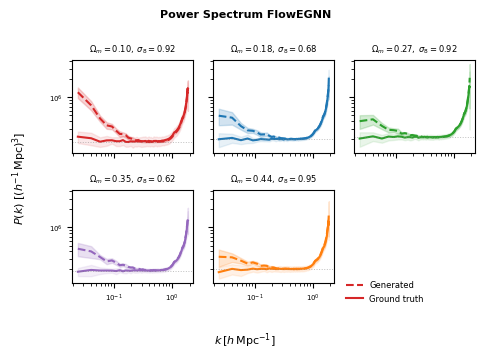

In [10]:
colors = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e']

fig, axes = plt.subplots(2, 3, figsize=(WIDTH_LATEX, 3.5), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i in range(n_eval):
    ax = axes_flat[i]
    
    gen_mean = np.mean(pk_gen[i], axis=0)
    gen_std = np.std(pk_gen[i], axis=0)

    # Generated: dashed + band
    ax.fill_between(k_vals, gen_mean - gen_std, gen_mean + gen_std,
                    alpha=0.2, color=colors[i])
    ax.plot(k_vals, gen_mean, linestyle='--', color=colors[i], label='Generated')

    # Ground truth: solid + band
    ax.plot(k_vals, pk_true_avg[i], color=colors[i], label='Ground truth')
    ax.fill_between(k_vals,
                    pk_true_avg[i] - pk_true_std[i],
                    pk_true_avg[i] + pk_true_std[i],
                    alpha=0.1, color=colors[i])

    # Shot noise per cosmology
    shot_noise_i = BoxSize**3 / mean_halo_counts[i]
    ax.axhline(shot_noise_i, color='gray', ls=':', alpha=0.5, linewidth=0.7)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(rf'$\Omega_m={eval_cosm[i,0]:.2f},\;\sigma_8={eval_cosm[i,4]:.2f}$',
                 fontsize=6, color=FONT_COLOR)
    ax.tick_params(which='both', labelsize=5, colors=FONT_COLOR)

# Hide the 6th subplot
axes_flat[5].set_visible(False)

fig.supxlabel(r"$k\,[h\,{\rm Mpc}^{-1}]$", fontsize=8, color=FONT_COLOR)
fig.supylabel(r'$P(k)$ $[(h^{-1}\,{\rm Mpc})^3]$', fontsize=8, color=FONT_COLOR)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=6, framealpha=0,
           bbox_to_anchor=(0.88, 0.12))

fig.suptitle("Power Spectrum FlowEGNN", fontsize=8, fontweight="bold")
plt.tight_layout()
plt.show()

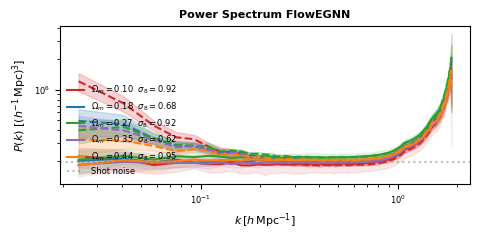

In [11]:
colors = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e']

fig, ax = plt.subplots(figsize=(WIDTH_LATEX, 2.5))

for i in range(n_eval):
    gen_mean = np.mean(pk_gen[i], axis=0)
    gen_std = np.std(pk_gen[i], axis=0)

    # Generated: dashed + band
    ax.fill_between(k_vals, gen_mean - gen_std, gen_mean + gen_std,
                    alpha=0.2, color=colors[i])
    ax.plot(k_vals, gen_mean, linestyle='--', color=colors[i])

    # Ground truth: solid + thin band
    ax.plot(k_vals, pk_true_avg[i], color=colors[i],
            label=rf'$\Omega_m = {eval_cosm[i,0]:.2f} \,\,\,\, \sigma_8 = {eval_cosm[i,4]:.2f}$')
    ax.fill_between(k_vals,
                    pk_true_avg[i] - pk_true_std[i],
                    pk_true_avg[i] + pk_true_std[i],
                    alpha=0.1, color=colors[i])

# Shot noise line using average halo count
avg_shot = BoxSize**3 / np.mean(mean_halo_counts)
ax.axhline(avg_shot, color='gray', ls=':', alpha=0.5, label='Shot noise')

ax.set_title("Power Spectrum FlowEGNN", fontsize=8, fontweight="bold")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r"$k\,[h\,{\rm Mpc}^{-1}]$", color=FONT_COLOR, fontsize=8)
ax.set_ylabel(r'$P(k)$ $[(h^{-1}\,{\rm Mpc})^3]$', color=FONT_COLOR, fontsize=8)
ax.tick_params(colors=FONT_COLOR, which='both', labelsize=6)
ax.legend(labelcolor=FONT_COLOR, fontsize=6, loc='lower left', framealpha=0)
plt.tight_layout()
plt.show()

In [ ]:
colors = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd', '#ff7f0e']

fig, ax = plt.subplots(figsize=(WIDTH_LATEX, 2.0))

for i in range(n_eval):
    gen_mean = np.mean(pk_gen[i], axis=0)
    gen_std = np.std(pk_gen[i], axis=0)

    ratio = gen_mean / pk_true_avg[i]
    ratio_err = gen_std / pk_true_avg[i]

    ax.fill_between(k_vals, ratio - ratio_err, ratio + ratio_err,
                    alpha=0.2, color=colors[i])
    ax.plot(k_vals, ratio, color=colors[i],
            label=rf'$\Omega_m = {eval_cosm[i,0]:.2f}$')

ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xscale('log')
ax.set_ylim(0.3, 1.7)
ax.set_xlabel(r"$k\,[h\,{\rm Mpc}^{-1}]$", fontsize=8)
ax.set_ylabel(r'$P_{\rm gen}(k) / P_{\rm true}(k)$', fontsize=8)
ax.set_title("Transfer Function", fontsize=8, fontweight="bold")
ax.tick_params(which='both', labelsize=6)
ax.legend(fontsize=6, loc='upper right', framealpha=0)
plt.tight_layout()
plt.show()